---
---

<div align="center">
<h1 align="center"><b>ADVANCED BIG DATA</b></h1>


<h3 align="center"><b>Construction d'un modèle de Machine Learning pour la prédiction du diabète</b></h3>

---
---

# Pre-processing

In [ ]:
import pandas as pd

# Import des données
data = pd.read_csv('diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Ce jeu de données contient 768 observations avec 8 caractéristiques médicales utilisées pour prédire si une personne est atteinte de diabète (Outcome = 1) ou non (Outcome = 0).

Les variables sont les suiavntes :
  - Pregnancies qui indique le nombre de grossesses;
  - Glucose qui indique le niveau de glucose dans le sang;
  - BloodPressure qui défininit la pression artérielle diastolique;
  - SkinThickness qui détermine l'épaisseur de la peau;
  - Insulin qui donne le niveau d'insuline dans le sang;
  - BMI qui indique l'indice de masse corporelle;
  - DiabetesPedigreeFunction qui évalue la probabilité de diabète en fonction de l’historique familial; autrement dit, cette variable indique la prédisposition de l'individu à être atteint du diabète;
  - Age qui donne l'âge du patient.

La variable Outcome est la variable cible.

C'est un problème d’apprentissage supervisé et plus précisément de classification. En effet, nous cherchons à prédire de la manière la plus fiable possible si un nouvel individu est diabétique ou non .

Il est important de noter que les mesures de ce jeu de données ne sont prises que sur des femmes indiennes.

In [ ]:
# Etude des statistiques
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


La variable Outcome a une moyenne de 0.35. Ainsi, environ 35% des patients sont diabétiques. Cela indique que le jeu de données est déséquilibré. C'est pourquoi nous utiliserons une technique d'oversampling sur notre ensemble d'entrainement.

Glucose, BloodPressure, SkinThickness, Insulin, BMI ont des minimums à 0. Cela est impossible, une pression sanguine à zéro signifie que l'individu est en arrêt cardiaque.
Nous allons devoir traiter ces valeurs manquantes.

La variable Insulin a une moyenne de 79.8 mais un écart-type de 115.2 avec un maximum à 846. Cela montre une grande dispersion dans les données et une potentielle présence d'individus atypiques.
Il en est de même pour la variable Pregnancies qui a une moyenne à 3.8 mais qui a un maximum à 17.

La variable Age a une médiane à 29 et un maximum à 81. Cela nous permet de dire que la population étudiée est relativement jeune.
Notons que la variable âge respecte bien la contrainte à savoir un minimum égal à 21 ans.

La variable BMI a moyenne de 32 avec des extrêmes allant jusqu’à 67.

La variable DiabetesPedigreeFunction a la majorité de ses valeurs autour de 0.47 mais son maximum est 2.42. Certains individus semblent posséder une forte prédiction à un terrain diabétique.

In [ ]:
# Selection des colonnes où les zéros représentent des valeurs manquantes
selected_features = [colonne for colonne in data.columns if colonne not in ['Pregnancies', 'DiabetesPedigreeFunction', 'Age', 'Outcome']]

In [ ]:
# Compter le pourcentage de valeurs nulles
pourcentage_zero = ((data[selected_features] == 0).mean()) * 100
pourcentage_zero.name = 'Pourcentage de 0'
pourcentage_zero

,Pourcentage de 0
Glucose,0.651042
BloodPressure,4.557292
SkinThickness,29.557292
Insulin,48.697917
BMI,1.432292


Nous décidons alors de supprimer les colonnes SkinThickness et Insulin car elles possèdent un pourcentage élevé de valeurs nulles.

Pour les autres variables, nous remplaçons ces valeurs inexistantes par des valeurs qui seraient cohérentes par rapport aux autres variables. Pour ce faire, nous utilions dans la suite de ce notebook un outil nommé KNNImputer qui fixe une valeur basée sur celles des observations voisines.

In [ ]:
from sklearn.impute import KNNImputer
import numpy as np

# Suppression des variables avec trop de valeurs manquantes
data_copy = data.copy()
data_copy.drop('SkinThickness', axis=1, inplace=True)
data_copy.drop('Insulin', axis=1, inplace=True)

data_copy

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,76,32.9,0.171,63,0
764,2,122,70,36.8,0.340,27,0
765,5,121,72,26.2,0.245,30,0
766,1,126,60,30.1,0.349,47,1


In [ ]:
# Remplacement des valeurs manquantes en utilisant KNNImputer
# Utilisation des plus proches voisins pour définir les valeurs manquantes
imputer = KNNImputer(missing_values=0)
data_copy[['Glucose', 'BloodPressure', 'BMI']] = imputer.fit_transform(data_copy[['Glucose', 'BloodPressure', 'BMI']])

# data_copy[selected_features] = data_copy[selected_features] .replace(0, np.nan)
# data_copy.fillna(data_copy.mean(), inplace=True)

In [ ]:
# Compter le pourcentage de valeurs nulles
pourcentage_zero = ((data_copy[['Glucose', 'BloodPressure', 'BMI']] == 0.0).mean()) * 100
pourcentage_zero.name = 'Pourcentage de 0'
pourcentage_zero

,Pourcentage de 0
Glucose,0.0
BloodPressure,0.0
BMI,0.0


Nous détectons encore des valeurs à zéro, nous décidons donc de supprimer les lignes restantes. En effet, elles ne sont pas trop nombreuses et cela ne nous fait donc pas trop perdre d'information.

In [ ]:
data_copy.drop(data_copy[data_copy['Glucose'] == 0.0].index, inplace=True)
data_copy.drop(data_copy[data_copy['BloodPressure'] == 0.0].index, inplace=True)
data_copy.drop(data_copy[data_copy['BMI'] == 0.0].index, inplace=True)

In [ ]:
# Compter le pourcentage de valeurs nulles
pourcentage_zero = ((data_copy[['Glucose', 'BloodPressure', 'BMI']] == 0.0).mean()) * 100
pourcentage_zero.name = 'Pourcentage de 0'
pourcentage_zero

,Pourcentage de 0
Glucose,0.0
BloodPressure,0.0
BMI,0.0


# Visualisation

Text(0.5, 1.0, 'Nombre de diabétiques (1) et non-diabétiques (0)')

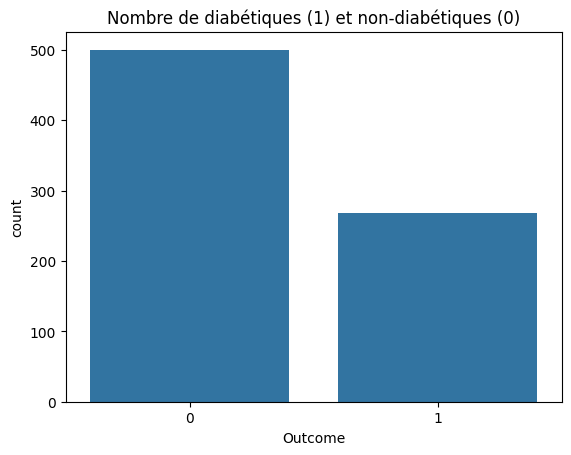

In [ ]:
import seaborn as sns

# Histogramme
sns.countplot(x="Outcome",data=data_copy).set_title("Nombre de diabétiques (1) et non-diabétiques (0)")

Nous observons que la classe diabétique est sous réprésentée. Ce déséquilibre risque de biaiser notre modèle.

En effet, cela augmente le risque de sur-apprentissage.

Ainsi, comme dit précédemment, nous ferons un oversampling de nos données d'entraînement.

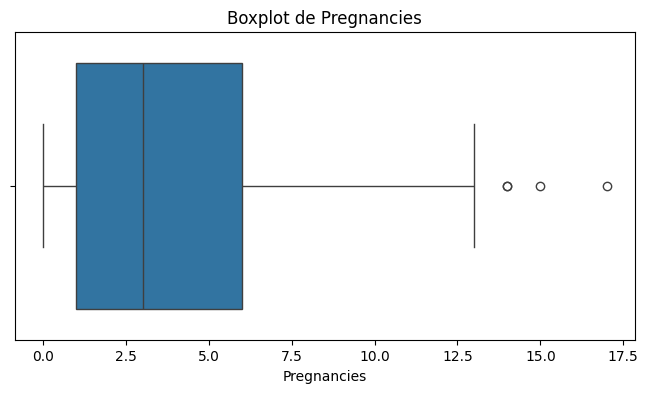

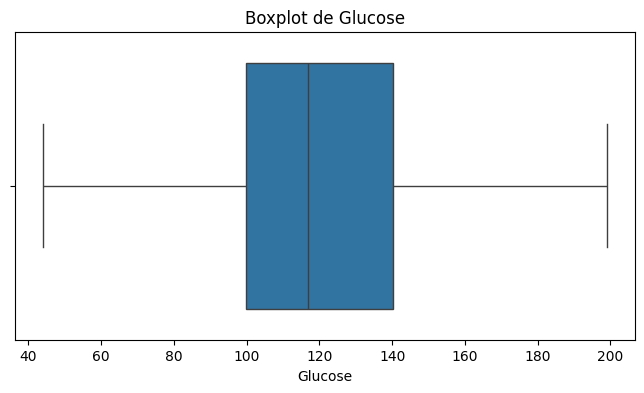

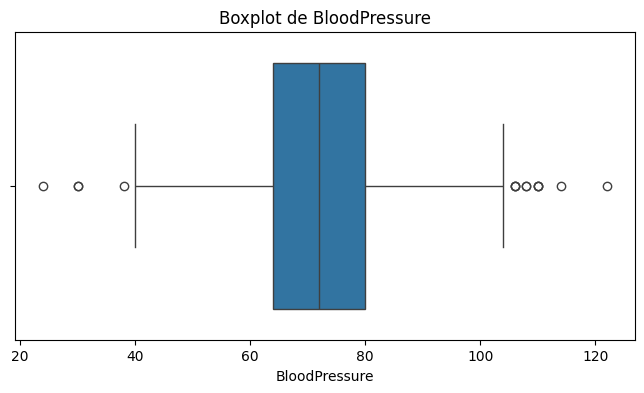

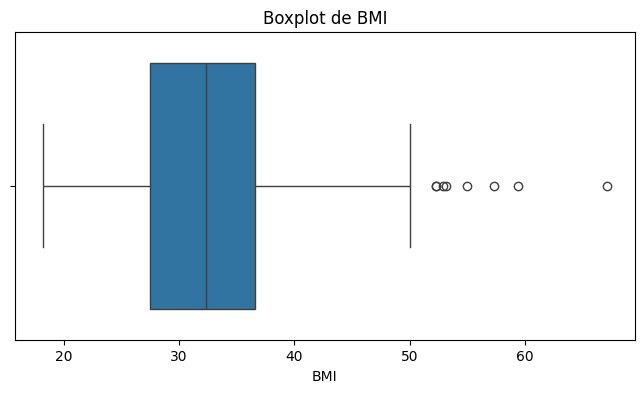

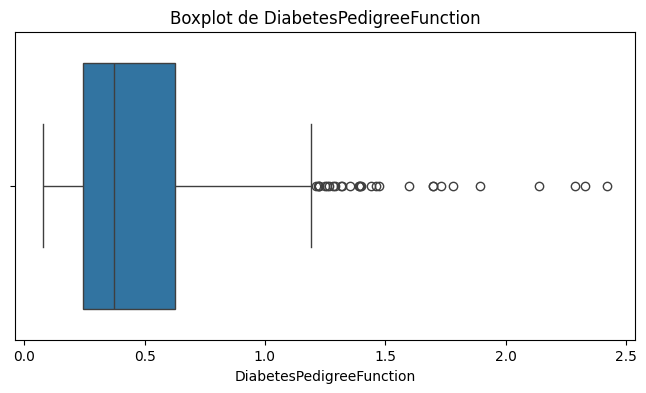

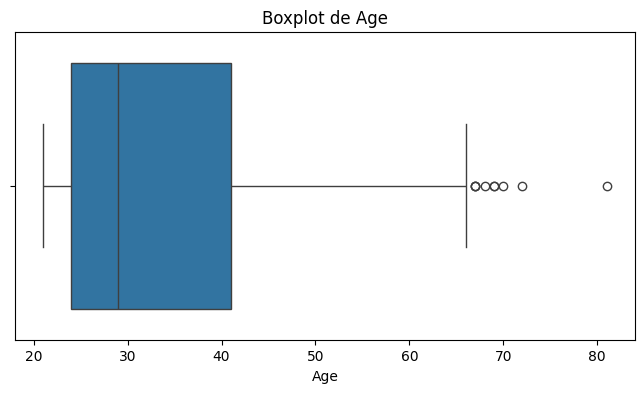

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot
for colonne in data_copy.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_copy[colonne])
    plt.title(f'Boxplot de {colonne}')
    plt.show()

Bien que nous observions des valeurs en dehors des moustaches, après les avoir étudiées, elles ne semblent pas anormales. C'est pourquoi nous avons décidé de les conserver dans notre jeu de données.

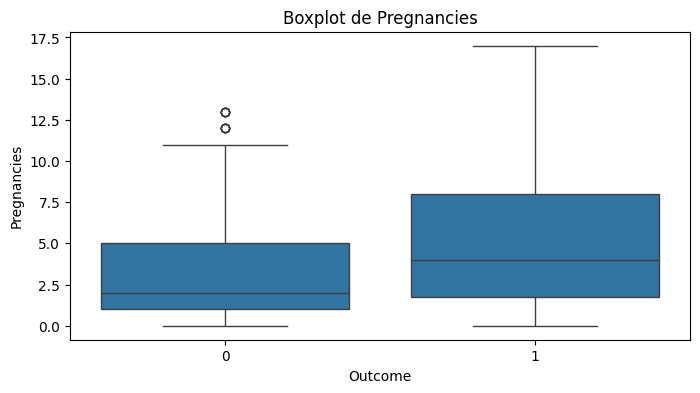

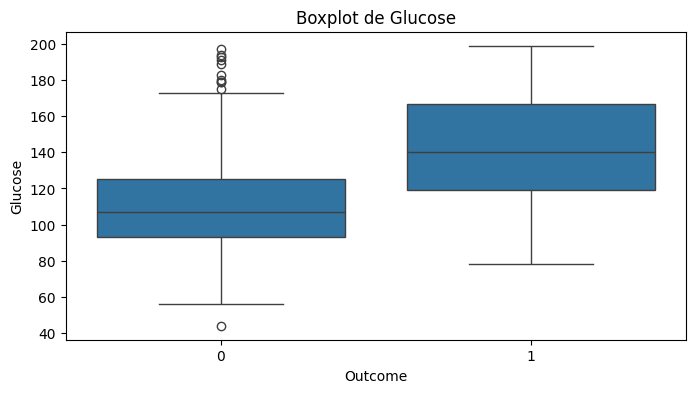

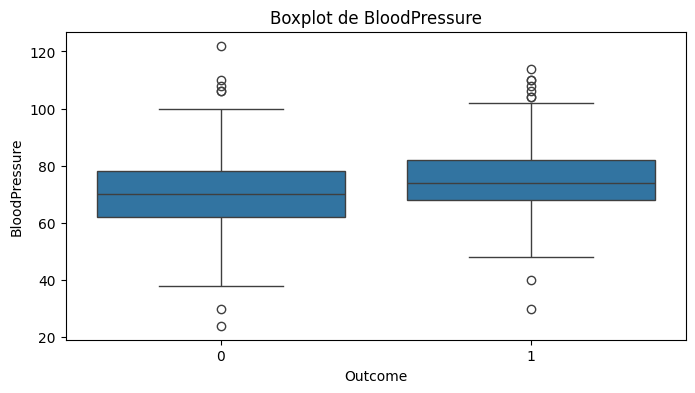

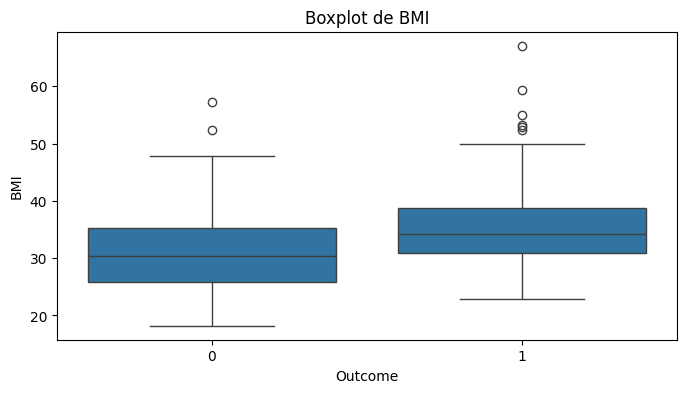

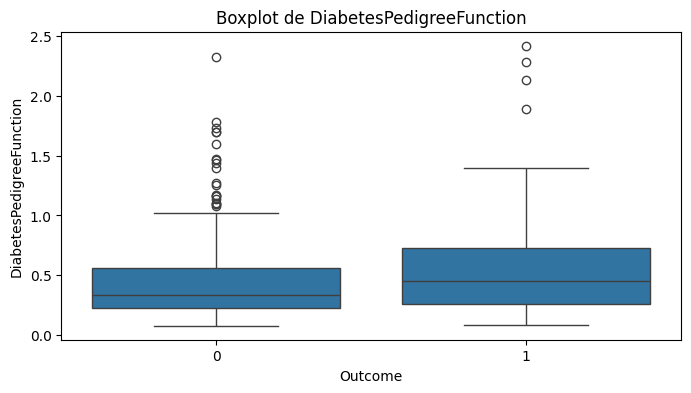

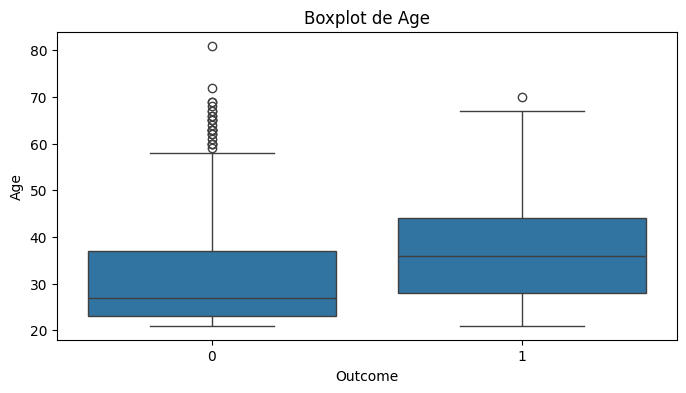

In [ ]:
# Boxplot
for colonne in data_copy.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_copy['Outcome'], y=data_copy[colonne])
    plt.title(f'Boxplot de {colonne}')
    plt.show()

On observe que les personnes diabétiques ont, globalement, des valeurs plus élevées pour chacune des variables étudiées. Cela est particulièrement vrai pour les variables BMI et Glucose.

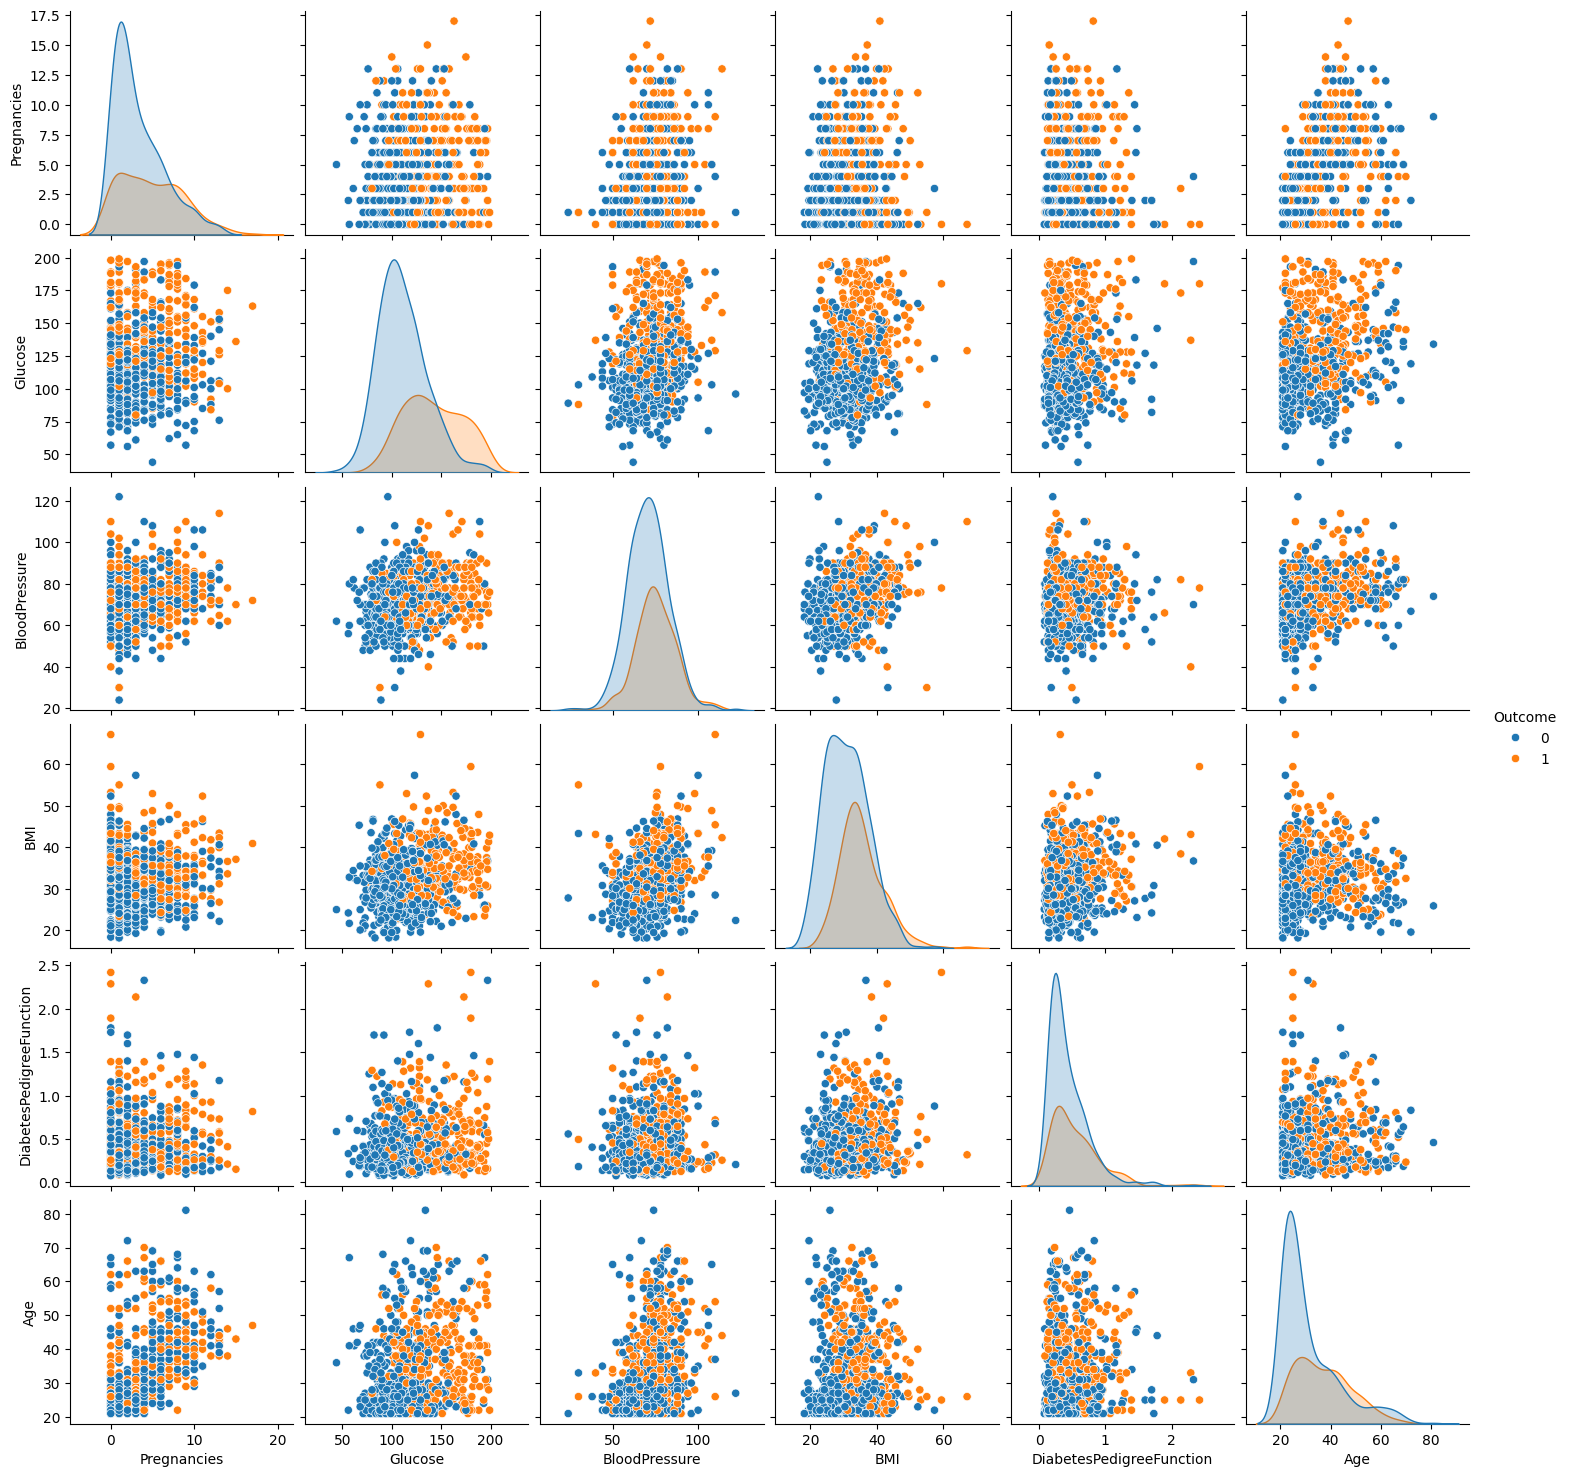

In [ ]:
# Pairplot
sns.pairplot(data_copy, hue='Outcome')

Nous remarquons que les classes sont assez mélangées et qu'il n'y a pas de séparations entre les classes.

De plus,  nous n'observons pas de lien linéaire entre les variables.

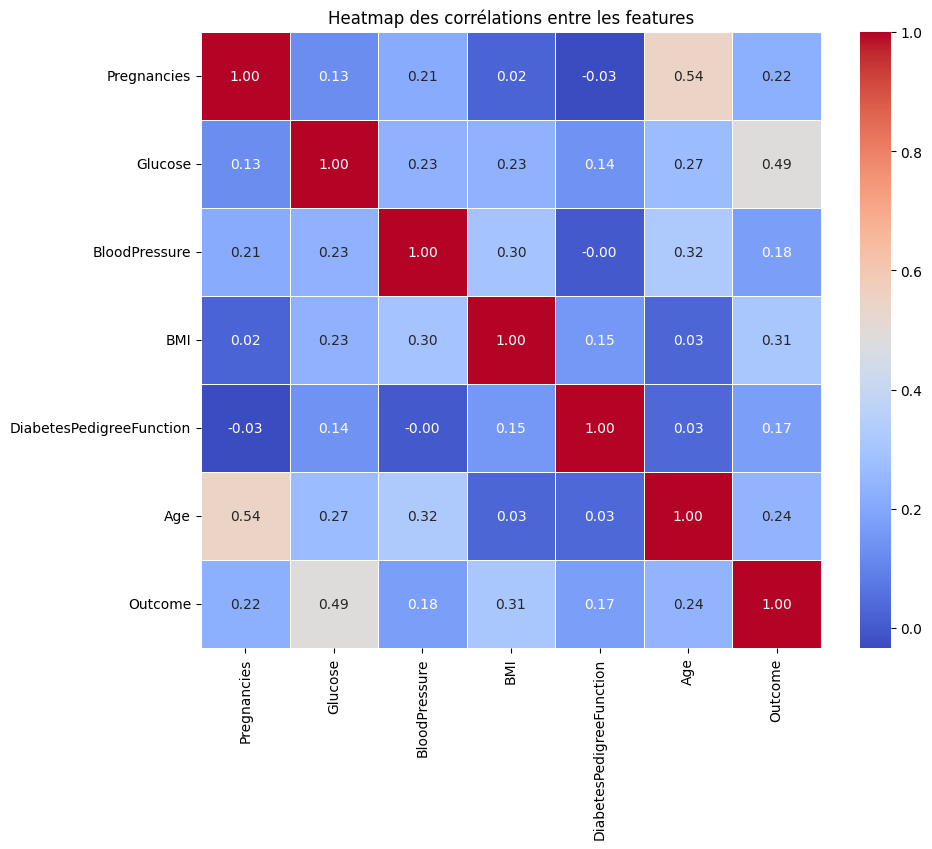

In [ ]:
# Corrélation des variables
correlation = data_copy.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap des corrélations entre les features')
plt.show()

Les variables ne montrent pas de corrélation suffisamment élevée pour supprimer une quelconque redondance.

In [ ]:
# Normalisation des données
data_to_normalize = data_copy.copy()
X = data_to_normalize.drop('Outcome', axis=1)
y = data_to_normalize['Outcome']

X_normalized = (X - X.mean()) / X.std()

Nous normalisons les données afin de leur donner à toute le même ordre de grandeur pour éviter que des valeurs trop élevées prennent le dessus sur les autres et ainsi, que nous perdions de l'information.

Cela garantit que chaque caractéristique contribue de manière équilibrée à l'apprentissage

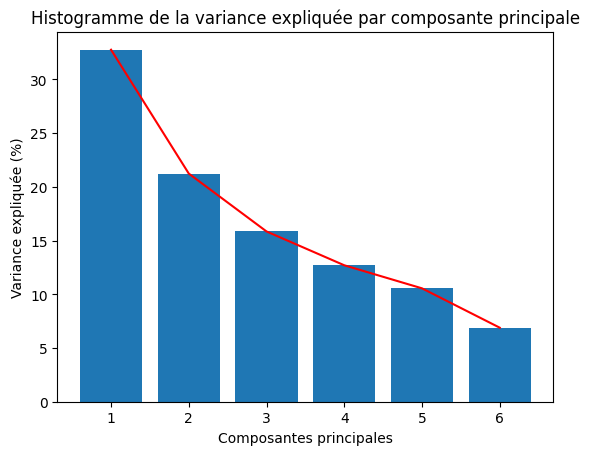

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Analyse en composantes principales
pca = PCA(n_components=X_normalized.shape[1])
res = pca.fit_transform(X_normalized)

variance_expliquee = pca.explained_variance_ratio_

plt.bar(range(1, len(variance_expliquee) + 1), variance_expliquee * 100)
plt.plot(range(1, len(variance_expliquee) + 1), variance_expliquee* 100, linestyle='-', color='r')
plt.xlabel('Composantes principales')
plt.ylabel('Variance expliquée (%)')
plt.title('Histogramme de la variance expliquée par composante principale')

plt.show()

(<Figure size 600x600 with 1 Axes>,
                              Dim 1     Dim 2
 Pregnancies              -0.655275  0.511851
 Glucose                  -0.573597 -0.335293
 BloodPressure            -0.660064 -0.140968
 BMI                      -0.402401 -0.655600
 DiabetesPedigreeFunction -0.148609 -0.549249
 Age                      -0.766778  0.385256)

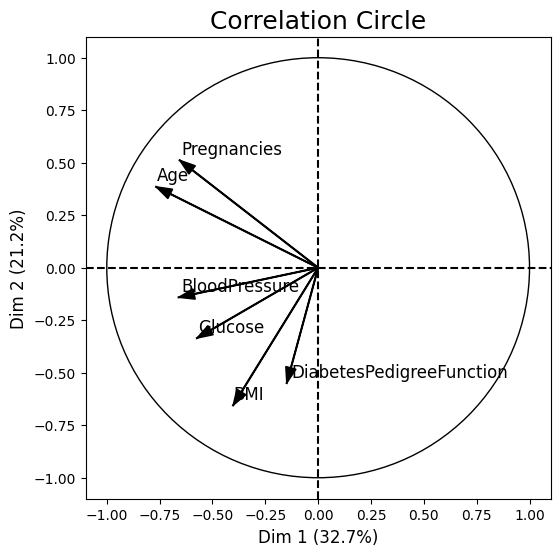

In [ ]:
from mlxtend.plotting import plot_pca_correlation_graph

plot_pca_correlation_graph(X_normalized, X_normalized.columns, dimensions=(1,2))

La variance cumulée expliquée par ces deux axes est d'environ 50%.

Nous considérons que cette réduction de dimension nous fait perdre trop de variabilité des données.

C'est pourquoi nous ne supprimons pas de variable supplémentaire.

# Machine Learning

## Division des ensembles

In [ ]:
data_model = data_copy.copy()

# Variables descriptives
new_X = data_model.drop('Outcome', axis=1)
# Variable cible
new_y = data_model['Outcome']

In [ ]:
new_X

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,33.6,0.627,50
1,1,85.0,66.0,26.6,0.351,31
2,8,183.0,64.0,23.3,0.672,32
3,1,89.0,66.0,28.1,0.167,21
4,0,137.0,40.0,43.1,2.288,33
...,...,...,...,...,...,...
763,10,101.0,76.0,32.9,0.171,63
764,2,122.0,70.0,36.8,0.340,27
765,5,121.0,72.0,26.2,0.245,30
766,1,126.0,60.0,30.1,0.349,47


In [ ]:
new_y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


Nous divisons notre jeu de données en trois ensembles:
  - L'ensemble d'entrainement pour régler les hyperparamètres et entraîner notre modèle;
  - L'ensemble de validation pour l'évaluation des modèles et le choix du meilleur modèle;
  - L'ensemble de test, utilisé uniquement à la fin, pour tester les performances finales de notre modèle sur des données que le modèle n'a jamais vu. Cela nous permet d'évaluer sa capacité de prédiction.

Pour ce faire, nous divisons notre jeu de données selon les porportions suivantes:
  - 70% pour l'ensemble d'entraînement;
  - 15% pour l'ensemble de validation;
  - 15% pour l'ensemble de test.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# Séparation du jeu de données
X_train, X_temp, y_train, y_temp = train_test_split(new_X, new_y, test_size=0.3, stratify=new_y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

# Augmentation des données d'entraînement avec SMOTE
# SMOTE permet de créer des données synthétiques
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Normalisation des données
scaler = StandardScaler()
scaler = scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

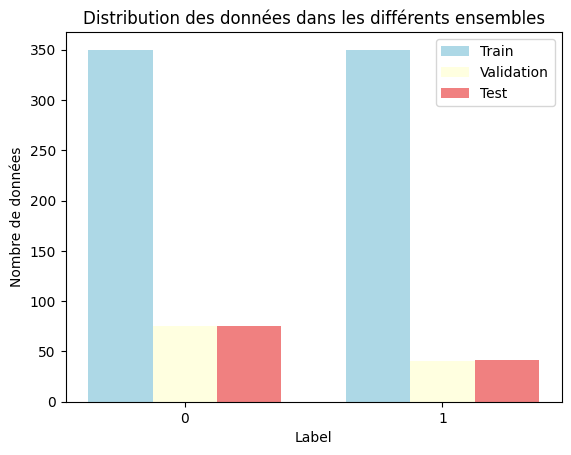

In [ ]:
# Vérification de la distribution des sous-ensembles
no_diabete_train = (y_train == 0).sum()
diabete_train = (y_train == 1).sum()
no_diabete_validation = (y_val == 0).sum()
diabete_validation = (y_val == 1).sum()
no_diabete_test = (y_test == 0).sum()
diabete_test = (y_test == 1).sum()

categories = ['0', '1']
train_values = [no_diabete_train, diabete_train]
validation_values = [no_diabete_validation, diabete_validation]
test_values = [no_diabete_test, diabete_test]
bar_width = 0.25
index = np.arange(len(categories))

plt.bar(index - bar_width, train_values, bar_width, label='Train', color='lightblue')
plt.bar(index, validation_values, bar_width, label='Validation', color='lightyellow')
plt.bar(index + bar_width, test_values, bar_width, label='Test', color='lightcoral')

plt.title('Distribution des données dans les différents ensembles')
plt.ylabel('Nombre de données')
plt.xlabel('Label')
plt.xticks(index, categories)
plt.legend()

plt.show()

Nous vérifions que nos sous ensembles sont bien équilibrés.

C'est bien le cas, cela est indispensable pour ne pas biaiser notre modèle.

## Entraînement des modèles

Pour l'ensemble des modèles suivant nous avons choisi d'utiliser RandomizedSearchCV afin de régler nos hyperparamètres.

Nous avons fais ce choix car RandomizedSearchCV est bien plus rapide que GridSearchCV compte tenu du nombre de paramètres que nous testons.

En effet, GridSearchCV teste exhaustivement toutes les combinaisons possibles, ce qui peut être très coûteux en temps de calcul, tandis que RandomizedSearchCV se limite à un nombre fixé de combinaisons choisies aléatoirement.

In [ ]:
X_train_scaled.shape

(700, 6)

In [ ]:
X_train

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,2,83.000000,66.000000,32.200000,0.497000,22
1,2,197.000000,70.000000,30.500000,0.158000,53
2,3,116.000000,76.800000,23.500000,0.187000,23
3,4,103.000000,60.000000,24.000000,0.966000,33
4,1,173.000000,74.000000,36.800000,0.088000,38
...,...,...,...,...,...,...
695,0,93.396762,83.236438,36.053280,0.403636,25
696,5,116.336490,74.000000,32.371504,0.641493,35
697,1,124.000000,68.622212,31.188917,0.681803,31
698,1,175.803249,88.000000,44.190872,0.536775,24


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Création et entraînement du modèle de Random Forest en utilisant divers paramètres afin de ne garder que le meilleur modèle
params = {
    'n_estimators': np.arange(10,200,20),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier()
random_search_rf = RandomizedSearchCV(rf, params, n_iter=50, cv=5, scoring='accuracy')
random_search_rf.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=50,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([ 10,  30,  50,  70,  90, 110, 130, 150, 170, 190])},
                   scoring='accuracy')

In [ ]:
print(f"Valeur moyenne de la validation croisée du meilleur estimateur pour Random Forest: {random_search_rf.best_score_ * 100:.2f}%")

# Récupération des meilleurs paramètres
meilleurs_params_rf = random_search_rf.best_params_
print("Meilleurs paramètres:", meilleurs_params_rf)

# Le modèle final est celui avec les meilleurs hyperparamètres
modele_final_rf = random_search_rf.best_estimator_

Valeur moyenne de la validation croisée du meilleur estimateur pour Random Forest: 80.57%
Meilleurs paramètres: {'n_estimators': np.int64(190), 'min_samples_split': 2, 'max_depth': 10, 'bootstrap': False}


Avec ce modèle, nous avons obtenu une précision de 80.57 % lors de la validation croisée.
Cette performance semble satisfaisante.

Notre modèle a les paramètres suivants :
- n_estimators: 190;
- min_samples_split: 2;
- max_depth: 10;
- bootstrap: False.

### Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

# Création et entraînement du modèle de Neural Network en utilisant divers paramètres afin de ne garder que le meilleur modèle
parameters_nn = {
    'hidden_layer_sizes': [(32,16), (16,8), (8,4)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'warm_start': [True, False],
    'max_iter': np.arange(50,100,10),
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'batch_size': [32],
    'early_stopping': [True, False]
}

nn = MLPClassifier(max_iter=1000)
random_search_nn = RandomizedSearchCV(nn, parameters_nn, n_iter=50, cv=5, scoring='accuracy')
random_search_nn.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

RandomizedSearchCV(cv=5, estimator=MLPClassifier(max_iter=1000), n_iter=50,
                   param_distributions={'activation': ['relu', 'tanh',
                                                       'logistic'],
                                        'alpha': [0.0001, 0.001, 0.01],
                                        'batch_size': [32],
                                        'early_stopping': [True, False],
                                        'hidden_layer_sizes': [(32, 16),
                                                               (16, 8),
                                                               (8, 4)],
                                        'learning_rate': ['constant',
                                                          'invscaling',
                                                          'adaptive'],
                                        'max_iter': array([50, 60, 70, 80, 90]),
                                        'solver': ['adam', 'sgd'],
                                        'warm_start': [True, False]},
                   scoring='accuracy')

In [ ]:
print(f"Valeur moyenne de la validation croisée du meilleur estimateur pour Neural Network: {random_search_nn.best_score_ * 100:.2f}%")

# Récupération des meilleurs paramètres
meilleurs_params_nn = random_search_nn.best_params_
print("Meilleurs paramètres:", meilleurs_params_nn)

# Le modèle final est celui avec les meilleurs hyperparamètres
modele_final_nn = random_search_nn.best_estimator_

Valeur moyenne de la validation croisée du meilleur estimateur pour Neural Network: 77.00%
Meilleurs paramètres: {'warm_start': False, 'solver': 'adam', 'max_iter': np.int64(80), 'learning_rate': 'constant', 'hidden_layer_sizes': (32, 16), 'early_stopping': False, 'batch_size': 32, 'alpha': 0.01, 'activation': 'tanh'}


Avec ce modèle, nous avons obtenu une précision de 77.00 % lors de la validation croisée.
Cette performance semble satisfaisante.

Notre modèle a les paramètres suivants :
- warm_start: False;
- solver: adam;
- max_iter: 80;
- learning_rate: constant;
- hidden_layer_sizes: 32 pour la première couche cachée et 16 pour la seconde;
- early_stopping: False;
- batch_size; 32;
- alpha: 0.01;
- activation: tanh.

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Création et entraînement du modèle de Logistic Regression en utilisant divers paramètres afin de ne garder que le meilleur modèle
params = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs", "newton-cg"],
    "max_iter": [1000]
}

lr = LogisticRegression()
random_search_lr = RandomizedSearchCV(lr, params, n_iter=50, cv=5, scoring='accuracy')
random_search_lr.fit(X_train_scaled, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 15 is smaller than n_iter=50. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=50,
                   param_distributions={'C': [0.001, 0.01, 0.1, 1, 10],
                                        'max_iter': [1000],
                                        'solver': ['liblinear', 'lbfgs',
                                                   'newton-cg']},
                   scoring='accuracy')

In [ ]:
print(f"Valeur moyenne de la validation croisée du meilleur estimateur pour Logistic Regression: {random_search_lr.best_score_ * 100:.2f}%")

# Récupération des meilleurs paramètres
meilleurs_params_lr = random_search_lr.best_params_
print("Meilleurs paramètres:", meilleurs_params_lr)

# Le modèle final est celui avec les meilleurs hyperparamètres
modele_final_lr = random_search_lr.best_estimator_

Valeur moyenne de la validation croisée du meilleur estimateur pour Logistic Regression: 72.71%
Meilleurs paramètres: {'solver': 'liblinear', 'max_iter': 1000, 'C': 0.1}


Avec ce modèle, nous avons obtenu une précision de 72.71 % lors de la validation croisée.
Cette performance semble satisfaisante.

Notre modèle a les paramètres suivants :
- solver: liblinear;
- max_iter: 1000;
- C: 0.1.

## Choix du meilleur modèle par évaluation sur l'ensemble de validation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Prediction des classes pour l'ensemble de validation pour les trois modèles testés
y_val_pred_rf = modele_final_rf.predict(X_val_scaled)
y_val_pred_nn = modele_final_nn.predict(X_val_scaled)
y_val_pred_lr = modele_final_lr.predict(X_val_scaled)

# Evaluation
print("------- Random Forest -------")
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"Précision sur l'ensemble de validation: {val_accuracy_rf * 100:.2f}%")
f1_rf = f1_score(y_val, y_val_pred_rf)
print(f"F1-score on Validation set: {f1_rf * 100:.2f}%")
recall_rf = recall_score(y_val, y_val_pred_rf)
print(f"Recall on Validation set: {recall_rf * 100:.2f}%")

print("------- Neural Network -------")
val_accuracy_nn = accuracy_score(y_val, y_val_pred_nn)
print(f"Précision sur l'ensemble de validation: {val_accuracy_nn * 100:.2f}%")
f1_nn = f1_score(y_val, y_val_pred_nn)
print(f"F1-score on Validation set: {f1_nn * 100:.2f}%")
recall_nn = recall_score(y_val, y_val_pred_nn)
print(f"Recall on Validation set: {recall_nn * 100:.2f}%")

print("------- Logistic Regression -------")
val_accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
print(f"Précision sur l'ensemble de validation: {val_accuracy_lr * 100:.2f}%")
f1_lr = f1_score(y_val, y_val_pred_lr)
print(f"F1-score on Validation set: {f1_lr * 100:.2f}%")
recall_lr = recall_score(y_val, y_val_pred_lr)
print(f"Recall on Validation set: {recall_lr * 100:.2f}%")

------- Random Forest -------
Précision sur l'ensemble de validation: 78.26%
F1-score on Validation set: 68.35%
Recall on Validation set: 67.50%
------- Neural Network -------
Précision sur l'ensemble de validation: 73.04%
F1-score on Validation set: 62.65%
Recall on Validation set: 65.00%
------- Logistic Regression -------
Précision sur l'ensemble de validation: 72.17%
F1-score on Validation set: 60.00%
Recall on Validation set: 60.00%


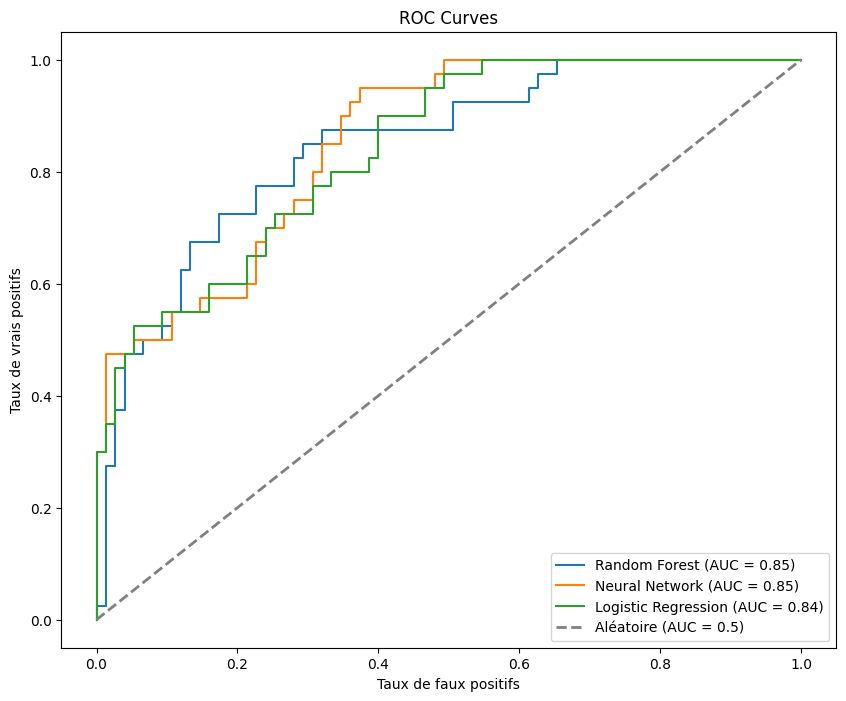

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcul de la ROC curve et le score AUC pour le modele Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_val, modele_final_rf.predict_proba(X_val_scaled)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calcul de la ROC curve et le score AUC pour le modele Neural Network
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_val, modele_final_nn.predict_proba(X_val_scaled)[:, 1])
roc_auc_nn = auc(fpr_nn, tpr_nn)

# Calcul de la ROC curve et le score AUC pour le modele Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_val, modele_final_lr.predict_proba(X_val_scaled)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)


# Afficahge des ROC curves pour tout les modèles
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_nn, tpr_nn, label='Neural Network (AUC = %0.2f)' % roc_auc_nn)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Affichage des métriques de chacun de nos modèles dans un tableau et le trier par ordre décroissant
metrics = {
    'Précision sur l\'ensemble de validation': [val_accuracy_rf, val_accuracy_nn, val_accuracy_lr],
    'F1-Score': [f1_rf, f1_nn, f1_lr],
    'Recall': [recall_rf, recall_nn, recall_lr],
    'AUC': [roc_auc_rf, roc_auc_nn, roc_auc_lr]
}

metrics_df = pd.DataFrame(metrics, index=['Random Forest', 'Neural Network', 'Logistic Regression'], columns=['Précision sur l\'ensemble de validation', 'F1-Score', 'Recall', 'AUC'])

sorted_metrics_df = metrics_df.sort_values(by=['Précision sur l\'ensemble de validation', 'F1-Score', 'Recall', 'AUC'], ascending=[False, False, False, False])
sorted_metrics_df

,Précision sur l'ensemble de validation,F1-Score,Recall,AUC
Random Forest,0.782609,0.683544,0.675,0.845667
Neural Network,0.730435,0.626506,0.650,0.854000
Logistic Regression,0.721739,0.600000,0.600,0.841000


Le meilleur modèle est le Radom Forest.

En effet, il possède les meilleures métriques pour la quasi totalité de celles étudiées.

## Evaluer les performances du modèle choisi

In [ ]:
# Choix du meilleur modèle
modele = sorted_metrics_df.index[0]
if modele == 'Random Forest':
    modele_final = modele_final_rf
elif modele == 'Neural Network':
    modele_final = modele_final_nn
else:
    modele_final = modele_final_lr

In [ ]:
# Prédiction des classes pour l'ensemble de test en utilisant le modèle choisi
y_test_pred = modele_final.predict(X_test_scaled)
# Calcul de l'accuracy sur l'ensemble de test
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Précision sur l\'ensemble de test: {test_accuracy * 100:.2f}%")

Précision sur l'ensemble de test: 77.59%


In [ ]:
from sklearn.metrics import confusion_matrix

# Calcul de la matrice de confusion pour l'ensemble de test
conf_matrice = confusion_matrix(y_test, y_test_pred)
conf_matrice_df = pd.DataFrame(
    conf_matrice,
    index=["Pas de diabète", "Diabète"],
    columns=["Prédit comme pas de diabète", "Prédit comme diabète"]
)
print("\nMatrice de confusion de l\'ensemble de test:")
conf_matrice_df


Matrice de confusion de l'ensemble de test:


,Prédit comme pas de diabète,Prédit comme diabète
Pas de diabète,64,11
Diabète,15,26


In [ ]:
from sklearn.metrics import precision_score

# Calcul de la précision, le recall et le f1_score
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"Precision (proportion de prédictions positives pour lesquelles la classe est correcte): {precision_test * 100:.2f}%")
print(f"Recall (proportion de données dans la classe positive pour laquelle la prédiction est correcte): {recall_test * 100:.2f}%")
print(f"F1-score: {f1_test * 100:.2f}%")

Precision (proportion de prédictions positives pour lesquelles la classe est correcte): 70.27%
Recall (proportion de données dans la classe positive pour laquelle la prédiction est correcte): 63.41%
F1-score: 66.67%


Notre ensemble de test a une précision de 77.59%, ce qui est vraiment satisfaisant.

En revanche, ce qui est important en médecine c'est de minimiser le taux de faux négatif.
En effet, ne pas détecter le diabète présent chez un patient serait très embêtant.
C'est pourquoi nous nous sommes aussi basés sur le recall pour valider notre modèle.

Ici le recall est à 63.41%, ce qui est insuffisant pour dire que notre modèle est performant.
Nous pouvions déjà présager de cela lorsque nous avons étudié notre pairplot.
En effet, sur ce dernier nous avions observé que les variables en notre possession ne nous permettent pas de séparer nos classes en deux groupes distincts.

Afin de palier ce problème, il faudrait créer de nouvelles variables soit de nouvelles données de terrains significatives, soit combiner certaines variables ou inclure des variables d'interaction.

In [ ]:
# Transformation en dataframe
X_test_df = pd.DataFrame(X_test)
y_test_df = pd.DataFrame(y_test)
X_test_df = pd.concat([X_test_df, y_test_df], axis=1)

# Récupération aléatoire de 5 individus par classe
diabete_index = np.where(y_test == 1)[0]
no_diabete_index = np.where(y_test == 0)[0]
index_diabete = np.random.choice(diabete_index, 5, replace=False)
index_no_diabete = np.random.choice(no_diabete_index, 5, replace=False)
diabete_df = X_test_df.iloc[index_diabete]
no_diabete_df = X_test_df.iloc[index_no_diabete]
selection_df = pd.concat([diabete_df, no_diabete_df], axis=0)

# Calcul des prédictions pour ces individus
diabete_pred = modele_final.predict(X_test_scaled)[index_diabete]
no_diabete_pred = modele_final.predict(X_test_scaled)[index_no_diabete]
predictions = np.concatenate([diabete_pred, no_diabete_pred])
predictions_df = pd.DataFrame(predictions, columns=['Predictions'])

# Concaténation des deux tableaux (features + label + prédiction)
selection_df = selection_df.reset_index(drop=True)
predictions_df = predictions_df.reset_index(drop=True)
df_final = pd.concat([selection_df, predictions_df], axis=1)
df_final

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome,Predictions
0,1,149.0,68.0,29.3,0.349,42,1,1
1,1,125.0,50.0,33.3,0.962,28,1,0
2,0,180.0,78.0,59.4,2.420,25,1,1
3,11,138.0,74.0,36.1,0.557,50,1,1
4,3,158.0,76.0,31.6,0.851,28,1,1
5,0,99.0,56.8,25.0,0.253,22,0,0
6,10,101.0,76.0,32.9,0.171,63,0,0
7,2,75.0,64.0,29.7,0.370,33,0,0
8,2,141.0,58.0,25.4,0.699,24,0,0
9,3,106.0,72.0,25.8,0.207,27,0,0


Le jeu de données ne comporte que des  données de femmes de nationalité indienne.

Néanmoins, cela engendre des problèmes de généralisation dans les prédicitons.
Ce modèle pourrait ne pas être prédictif pour des hommes ou des individus d'autres nationalités étant donné que les facteurs de risque peuvent varier selon le sexe et l'origine ethnique.

Ainsi, il serait intéressant de collecter des données représentatives de la population mondiale et de faire cette même analyse sur ce nouveau jeu de données.